In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [16]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [17]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [18]:
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])
crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [19]:
proporciones = df.groupby("category")["isBestSeller"].mean().sort_values(ascending=False)
proporciones

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
                                    ...   
Bedding Collections               0.000000
CPUs                              0.000000
CD, Disc & Tape Players           0.000000
Blank Media Cases & Wallets       0.000000
eBook Readers & Accessories       0.000000
Name: isBestSeller, Length: 296, dtype: float64

CON LOS RESULTADOS QUE OBTUVIMOS PODEMOS AFIRMAR QUE LAS CATEGORIAS GROCERY, SMART HOME Y HEALTH SON LAS QUE TIENEN LA POSIBILIDAD DE TENER UN EXITO DE VENTAS. 

In [20]:
from scipy.stats import chi2_contingency

In [21]:
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(36540.20270061387), np.float64(0.0))

TENIENDO COMO RESULTADO QUE EL P_VALUE ES 0,0 PODEMOS DECIR QUE LA CATEGORIA INFLUYE EN LA PROBABILIDAD DE QUE EL PRODUCTO VENDIDO SE CONVIERTA EN UN BEST SELLER. 

In [22]:
from scipy.stats.contingency import association

In [23]:
association(crosstab_result, method="cramer")

0.1222829439760564

SEGUN EL VALOR OBTENIDO A TRAVES DEL METODO CRAMER PODEMOS AFIRMAR QUE LA RELACIÓN ENTRE BEST SELLER Y CATEGORY ES DEBIL. 

<Axes: xlabel='category'>

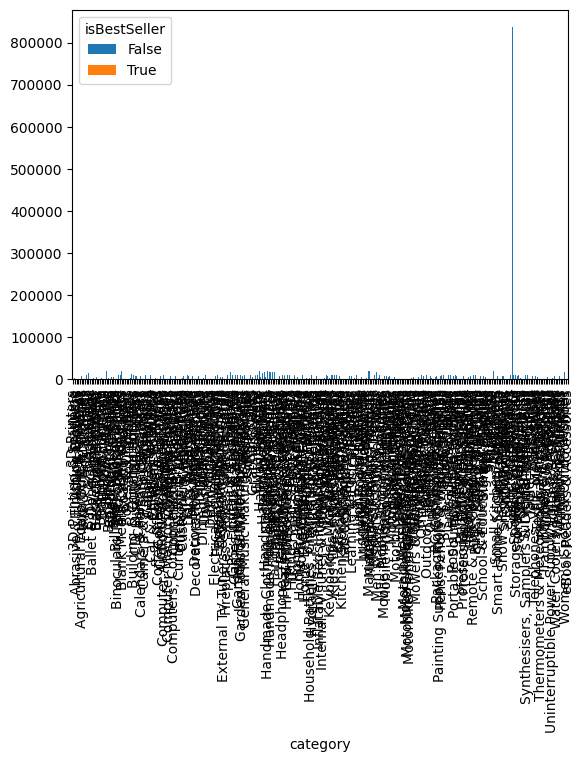

In [24]:
crosstab_result.plot(kind="bar", stacked=True)

In [42]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
    
    # Define bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    
# Identify the outliers
df_precios = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]


In [43]:
df_precios.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [49]:
df_precios1 = df_precios["category"].value_counts().sort_values(ascending=False).head(20)
df_precios1

category
Sports & Outdoors                         694092
Beauty                                     19233
Bath & Body                                19050
Manicure & Pedicure Products               18904
Handmade Clothing, Shoes & Accessories     18811
Make-up                                    18718
Skin Care                                  18686
Hair Care                                  18625
Birthday Gifts                             18398
Handmade Gifts                             17948
Handmade Home Décor                        17675
Luggage and travel gear                    17557
Women                                      17476
Fragrances                                 17431
Handmade Kitchen & Dining                  17346
Handmade Artwork                           17269
Handmade Home & Kitchen Products           17175
Handmade Jewellery                         17135
Men                                        16596
Baby                                       14883
Name: count

In [45]:
top_20 = df_precios1.index
top_20

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

In [46]:
df_top20 = df_precios[df_precios["category"].isin(top_20)]
df_top20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


C:\Users\HP\AppData\Local\Temp\ipykernel_21668\745227257.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")


<Axes: xlabel='price', ylabel='category'>

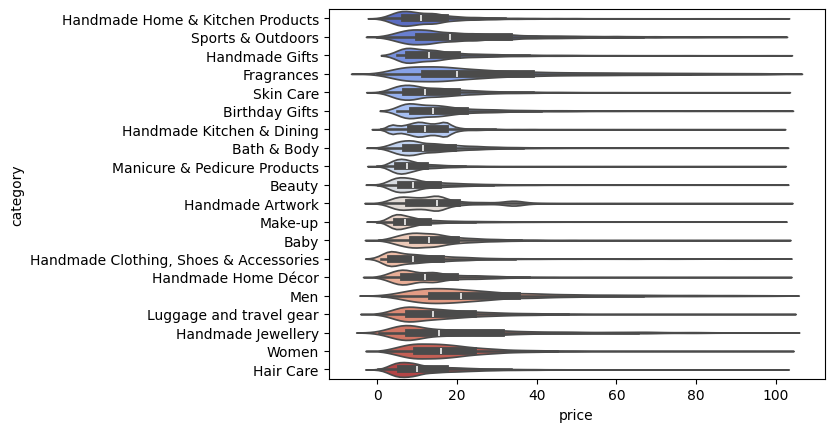

In [50]:
sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")

In [54]:
df_precios.groupby("category")["price"].median().sort_values(ascending=False)

category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

LA CATEGORIA DESKTOP PCs ES LA QUE TIENE LA MEDIAN MAS ALTA DE PRECIO. 

In [ ]:
df_precios2 = df_precios["category"].value_counts().sort_values(ascending=False).head(10)
df_precios2


category
Sports & Outdoors                         694092
Beauty                                     19233
Bath & Body                                19050
Manicure & Pedicure Products               18904
Handmade Clothing, Shoes & Accessories     18811
Make-up                                    18718
Skin Care                                  18686
Hair Care                                  18625
Birthday Gifts                             18398
Handmade Gifts                             17948
Name: count, dtype: int64

In [60]:
top10 = df_precios2.index
top10

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts'],
      dtype='object', name='category')

In [62]:
df_top10 = df_precios[df_precios["category"].isin(top10)]
df_top10

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
82163,89483,B07DLGZ828,Neutrade GoPro 3M Sticky Pads Double Sided Adh...,4.2,3116,6.49,False,0,Sports & Outdoors
82164,89484,B09HGZHXJT,"WOLFANG Action Camera 4K 20MP GA100, Waterproo...",4.2,2594,49.99,False,0,Sports & Outdoors
82167,89487,B08LD4VXGL,FitStill 60M/196FT Waterproof Case for Go Pro ...,4.5,9879,16.98,True,0,Sports & Outdoors
82168,89488,B07QDMLMJH,Nextbase Powered Mount Variations For Cameras ...,4.7,1223,19.95,False,0,Sports & Outdoors
82169,89489,B09TQMCNY7,WOLFANG Action Camera GA100 with 64GB microSDX...,4.2,55,49.99,False,0,Sports & Outdoors
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


In [63]:
df_top10.groupby("category")["price"].mean().sort_values(ascending=False)

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_21668\3268767732.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x='price', y='category', palette="coolwarm")


<Axes: xlabel='price', ylabel='category'>

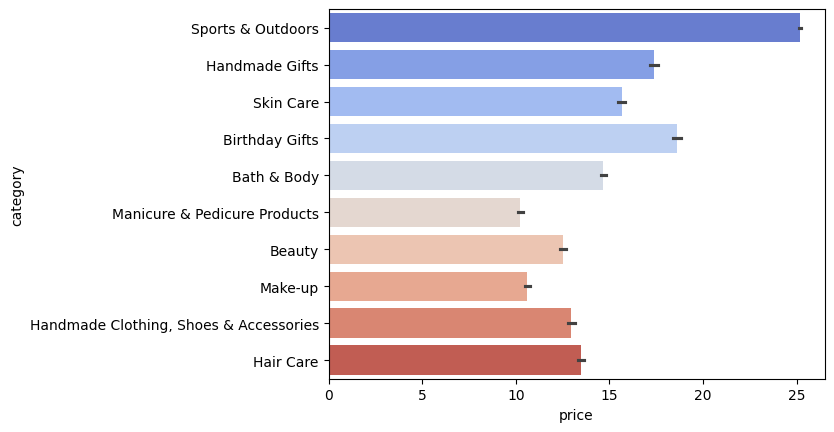

In [65]:
sns.barplot(data=df_top10, x='price', y='category', palette="coolwarm")

PODEMOS DECIR QUE DE LAS CATEGORIAS TOP 10, SPORTS ES LA QUE TIENE EL VALOR MAYOR DE AVG.

In [66]:
df_precios.groupby("category")["price"].mean().sort_values(ascending=False)

category
Motherboards             68.772432
Boxing Shoes             67.417803
Desktop PCs              66.915562
Tablets                  66.552971
Graphics Cards           65.103509
                           ...    
Bedding Accessories       8.835220
Adapters                  8.750197
Signs & Plaques           8.210513
Arts & Crafts             8.006540
Office Paper Products     6.876369
Name: price, Length: 296, dtype: float64

PODEMOS AFIRMAR QUE LA CATEGORIA MOTHERBOARDS ES LA QUE TIENE EL VALOR PROMEDIO MAS ALTO ENTRE TODAS LAS CATEGORIAS. 

C:\Users\HP\AppData\Local\Temp\ipykernel_21668\2622722678.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='stars', y='category', palette="coolwarm")


<Axes: xlabel='stars', ylabel='category'>

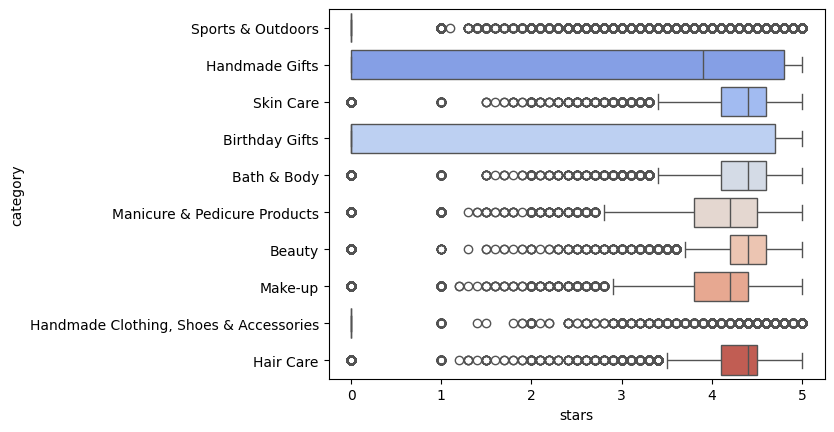

In [69]:
sns.boxplot(data=df_top10, x='stars', y='category', palette="coolwarm")

EN ESTE GRAFICO PODEMOS OBSERVAR QUE HAY UNA GRAN DISPERCIÓN GENERAL HACIA LA IZQUIERDA O EL RATING "CERO" PERO A SU VEZ PODEMOS CONFIRMAR QUE LA CATEGORIA BEAUTY ES LA QUE TIENE UNA MEDIAN MAS "EQUILIBRADA".

In [70]:
df_precios.groupby("category")["stars"].mean().sort_values(ascending=False)

category
Luxury Food & Drink                       4.544140
Grocery                                   4.469414
Laptop Accessories                        4.449600
Health & Personal Care                    4.439549
Arts & Crafts                             4.432942
                                            ...   
Boxing Shoes                              0.160470
Motorbike Handlebars, Controls & Grips    0.134289
Motorbike Electrical & Batteries          0.105697
3D Printing & Scanning                    0.094067
CD, Disc & Tape Players                   0.048834
Name: stars, Length: 296, dtype: float64

PODEMOS AFIRMAR QUE LA CATEGORIA LUXURY ES LA QUE TIENE EL MEJOR PROMEDIO DE RATING ALTOS SEGUIDA DE GROCERY Y LAPTOP ACCESSORIES. 

In [71]:
correlation = df_precios['price'].corr(df['stars'])
correlation

np.float64(-0.07767299878181323)

A PARTIR DEL CALCULO DE LA CORRELACION DE PEARSON PODEMOS AFIRMAR QUE NO LO EXISTE DADO QUE SU RESULTADO HA SIDO NEGATIVO Y CASI 0.

In [73]:
correlation2 = df_precios['price'].corr(df['stars'], method='spearman')
correlation2

np.float64(-0.06679697280768307)

PODEMOS AFIRMAR QUE DEL CALCULO DE LA CORRELACION DE SPERMAN EL PRECIO NO PARECE INFLUIR DE FORMA SIGNIFICATIVA EN LA VALORACION DEL PRODUCTO.

Podemos afirmar que la categoria Sports & Outdorrs domina ampliamente la cantidad de productos. 

<Axes: xlabel='price', ylabel='stars'>

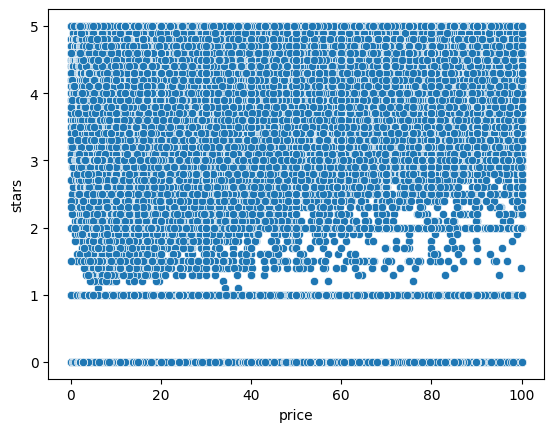

In [76]:
sns.scatterplot(data=df_precios, x='price', y='stars')

EL GRAFICO LO QUE NOS MUESTRA ES QUE NO HAY UNA RELACION CLARA ENTRE PRECIO Y VALORACION DEL PRODUCTO, SE VE UNA GRAN ACUMULACION DE PRECIOS ENTRE EL RATING 3 Y 5. 

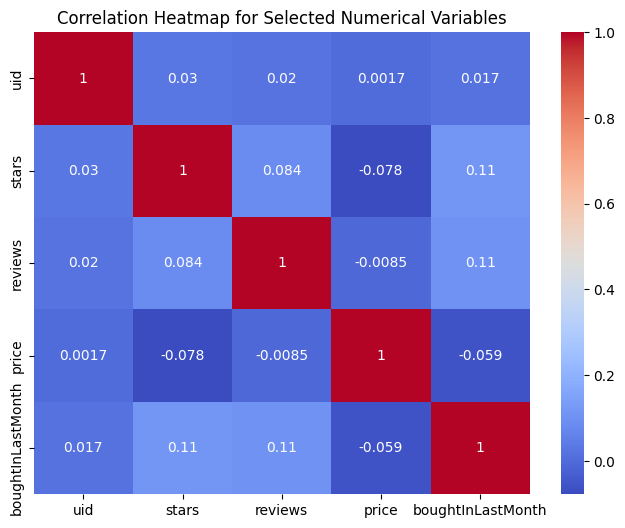

In [78]:
corr_matrix = df_precios.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

EL MAPA NOS CONFIRMA QUE HAY UNA NULA CORRELACION ENTRE PRICE Y STARS, COMO ASI TAMBIÉN SALVO ALGUNA EXCEPCION, TAMPOCO HAY CORRELACION ENTRE LAS VARIABLES NUMERICAS. 

In [ ]:
import scipy.stats as stats


stats.probplot(df_precios["price"], dist="norm", plot=plt)

In [79]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.6 MB 16.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 13.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ----


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import statsmodels.api as sm

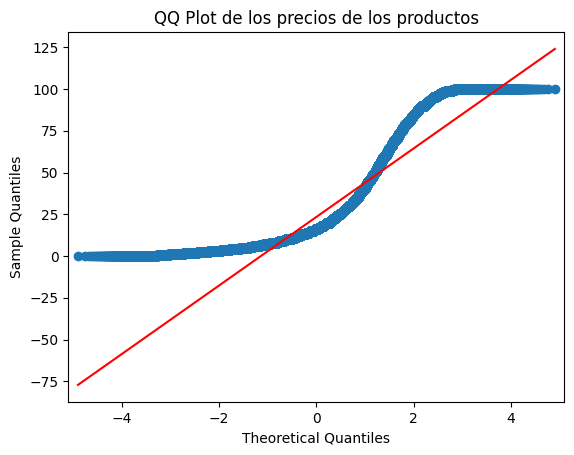

In [81]:
sm.qqplot(df_precios["price"], line="s")

plt.title("QQ Plot de los precios de los productos")
plt.show()

LAS COLAS DE LA LINEA SE ALEJAN DE LA LINEA DE REFERENCIA LO QUE NOS CONFIRMA QUE LOS PRECIOS NO SIGUEN UNA DISTRIBUCION NORMAL. 